In [1]:
import math

import numpy as np

from sizing.config import AircraftConfig, MissionConfig, AircraftTypes, Engine, EngineType, MissionTypes
from sizing.config import Aerodynamics
from sizing.constraint_diagram import ConstraintPlotter, CruiseConstraint, TakeoffConstraint, ClimbConstraint, \
    BalancedTakeoffConstraint, LandingConstraint, StallConstraint
from sizing.empty_weight_fraction import EmptyWeightFraction, AircraftTypeEmptyWeight
from sizing.mission import MissionWeightFraction, ConstantFuelFractionMissionItem, ClimbAndAccelerateMissionItem, \
    CruiseMissionItem, LoiterMissionItem
from sizing.utils import M_TO_FEET, KG_TO_POUND, NMI_TO_M, MIN_TO_S, g
import fluids

CRUISE_MACH = 0.8
CRUISE_ALTITUDE = 36000 / M_TO_FEET

WEIGHT_PER_PERSON = 230 / KG_TO_POUND
PAX_NUMBER = 400
CREW_NUMBER = 10

MISSION_CRUISE_RANGE = 3500 * NMI_TO_M
DIVERSION_RANGE = 200 * NMI_TO_M

LOITER_AT_DIVERSION = 30 * MIN_TO_S

MAX_LIFT_TO_DRAG = 17
ASPECT_RATIO = 9
FACTOR_E = 0.9

TAKEOFF_FIELD_LENGTH = 9000 / M_TO_FEET
LANDING_FIELD_LENGTH = 9000 / M_TO_FEET
TAKEOFF_ALTITUDE = 0
LANDING_ALTITUDE = 0
CLIMBOUT_ALTITUDE = 400 / M_TO_FEET
STALL_SPEED = 74

config = AircraftConfig(
    mission=MissionConfig(AircraftTypes.TRANSPORT_JET),
    aerodynamics=Aerodynamics(
        AR = ASPECT_RATIO,
        E = FACTOR_E,
        L_D_max = MAX_LIFT_TO_DRAG,
    ),
    engine=Engine(
        type=EngineType.JET,
        sfc=0.0000133128,
        thrust=10000
    ),
    W0= 230000,
    souls_onboard=CREW_NUMBER+PAX_NUMBER,
    weight_per_person=WEIGHT_PER_PERSON,
    cruise_mach=CRUISE_MACH,
    cruise_altitude=CRUISE_ALTITUDE,
    takeoff_field_length=TAKEOFF_FIELD_LENGTH,
    landing_field_length=LANDING_FIELD_LENGTH,
    stall_speed=STALL_SPEED,
    takeoff_altitude=TAKEOFF_ALTITUDE,
    landing_altitude=LANDING_ALTITUDE
)

print(config)

class Solver:
    config: AircraftConfig
    empty_weight_fraction: EmptyWeightFraction
    mission_weight_fraction: MissionWeightFraction
    def __init__(self, conf: AircraftConfig, empty_weight_fraction: EmptyWeightFraction, mission_weight_fraction: MissionWeightFraction):
        self.config = conf
        self.empty_weight_fraction = empty_weight_fraction
        self.mission_weight_fraction = mission_weight_fraction

        self.mission_weight_fraction.set_config(self.config)
        self.empty_weight_fraction.set_config(self.config)

    def estimate_w0(self):
        mission_weight_fraction = self.mission_weight_fraction.total_fuel_weight_fraction()
        empty_weight_fraction = self.empty_weight_fraction.empty_weight_fraction()

        w_fixed = self.config.souls_onboard * self.config.weight_per_person

        w_0 = w_fixed / (1-(mission_weight_fraction + empty_weight_fraction))
        return w_0


empty_weight_fraction_calc = EmptyWeightFraction(AircraftTypeEmptyWeight.BOMBER_AND_TRANSPORT)

takeoff_fraction_items = [
    ConstantFuelFractionMissionItem(MissionTypes.WARMUP),
    ConstantFuelFractionMissionItem(MissionTypes.TAXI),
]

cruise_fraction_items = takeoff_fraction_items + [
    ConstantFuelFractionMissionItem(MissionTypes.TAKEOFF),
    ConstantFuelFractionMissionItem(MissionTypes.CLIMB),
]

mission_weight_fraction_calc = MissionWeightFraction(cruise_fraction_items + [
    ClimbAndAccelerateMissionItem(0, CRUISE_MACH), # conservative estimate, should be something like V2
    CruiseMissionItem(CRUISE_MACH * fluids.ATMOSPHERE_1976(CRUISE_ALTITUDE).v_sonic, MISSION_CRUISE_RANGE),
    ConstantFuelFractionMissionItem(MissionTypes.DESCENT),
    ConstantFuelFractionMissionItem(MissionTypes.CLIMB),
    ClimbAndAccelerateMissionItem(0, CRUISE_MACH), # conservative estimate, should be something like V2 again
    ConstantFuelFractionMissionItem(MissionTypes.DESCENT),
    LoiterMissionItem(None, LOITER_AT_DIVERSION),
    ConstantFuelFractionMissionItem(MissionTypes.LANDING),
])

solver = Solver(config, empty_weight_fraction_calc, mission_weight_fraction_calc)

AircraftConfig(mission=MissionConfig(aircraft_type=<AircraftTypes.TRANSPORT_JET: '4'>), aerodynamics=Aerodynamics(AR=9, E=0.9, L_D_max=17, CL_max_to=1.9, CL_max_l=2.4, dCD0_to=0.015, dCD0_l=0.085), engine=Engine(type=<EngineType.JET: '1'>, sfc=1.33128e-05, thrust=10000, prop_efficiency=None), souls_onboard=410, weight_per_person=104.32622720528633, W0=230000, takeoff_field_length=2743.2007483451644, landing_field_length=2743.2007483451644, takeoff_altitude=0, landing_altitude=0, stall_speed=74, cruise_mach=0.8, cruise_altitude=10972.802993380657, loiter_mach=None, loiter_altitude=None)


In [2]:

while True:
    initial_w_0 = config.W0

    w_0_estimate = solver.estimate_w0()

    error = w_0_estimate - initial_w_0
    print(f"Estimated W0: {w_0_estimate:.2f} kg, Error: {error:.2f} kg")

    config.W0 = w_0_estimate

    if abs(error) < 1:
        print("Converged!")
        break

Estimated W0: 210516.03 kg, Error: -19483.97 kg
Estimated W0: 212751.95 kg, Error: 2235.92 kg
Estimated W0: 212482.03 kg, Error: -269.92 kg
Estimated W0: 212514.42 kg, Error: 32.39 kg
Estimated W0: 212510.53 kg, Error: -3.89 kg
Estimated W0: 212511.00 kg, Error: 0.47 kg
Converged!


In [3]:

cruise_mf = MissionWeightFraction(cruise_fraction_items, config).fuel_weight_fraction()
takeoff_mf = MissionWeightFraction(takeoff_fraction_items, config).fuel_weight_fraction()


cp = ConstraintPlotter(
    config=config,
    wing_load_range=(1000, 15000),
    constraints=[
        CruiseConstraint("cruise", config.cruise_altitude, config.cruise_airspeed, cruise_mf),
        TakeoffConstraint("takeoff field length", config.takeoff_altitude, 1.2*config.stall_speed, takeoff_mf, 0.03),
        BalancedTakeoffConstraint("balanced field length", config.takeoff_altitude, 1.2*config.stall_speed, takeoff_mf),
        ClimbConstraint("climb segment 1", config.takeoff_altitude, 1.2*config.stall_speed, takeoff_mf, 0.024),
        ClimbConstraint("climb segment 2", config.takeoff_altitude+CLIMBOUT_ALTITUDE, 1.25*config.stall_speed, takeoff_mf, 0.012),
        LandingConstraint("landing", config.landing_altitude, 1.2*config.stall_speed, 0.85, 0.45),
        StallConstraint("stall", config.landing_altitude, config.stall_speed, 0.85)
    ]
)

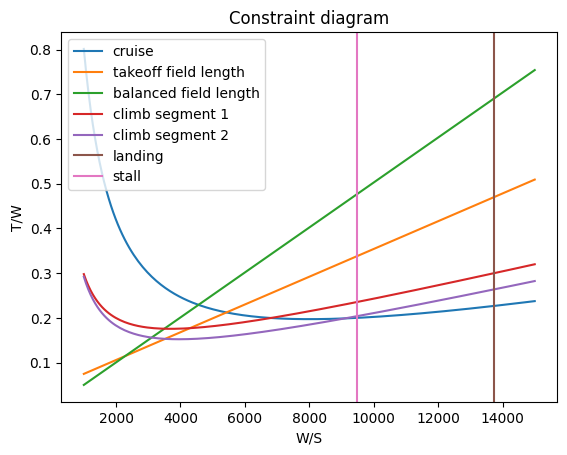

Wing area: 336.5900008070052
Thrust required: 646925.981551064
Wingspan: 55.03916793759738


In [4]:

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.subplots()

cp.draw_tw_wl_diagram(ax)

ax.set_title('Constraint diagram')
ax.legend()
ax.set_xlabel('W/S')
ax.set_ylabel('T/W')

T_to_W = 0.31
W_L = 6200

plt.show()
S = config.W0*g / W_L
Tr = T_to_W * config.W0 * g
print(f"Wing area: {S}")
print(f"Thrust required: {Tr}")

wingspan = math.sqrt(config.aerodynamics.AR*S)
print(f"Wingspan: {wingspan}")

In [5]:
rho_cruise = fluids.ATMOSPHERE_1976(config.cruise_altitude).rho
c = fluids.ATMOSPHERE_1976(config.cruise_altitude).v_sonic
fuel_weight = config.W0 * mission_weight_fraction_calc.total_fuel_weight_fraction()
avg_cruise_weight = config.W0 - 1/2 * fuel_weight

cruise_cl = 2 * avg_cruise_weight * g / (rho_cruise * (config.cruise_mach*c)**2 * S * 0.9)

max_cruise_cl = 2 * config.W0 * g / (rho_cruise * (config.cruise_mach*c)**2 * S * 0.9)

rho = fluids.ATMOSPHERE_1976(0).rho
cl_max_needed = 1.111 * 2 * W_L / (rho * config.stall_speed**2)

print(f"Cruise Cl: {cruise_cl:.2f}, max cruise Cl: {max_cruise_cl:.2f} Max Cl needed: {cl_max_needed:.2f}")

Cruise Cl: 0.56, max cruise Cl: 0.67 Max Cl needed: 2.05


So a rather THICC airfoil is called for

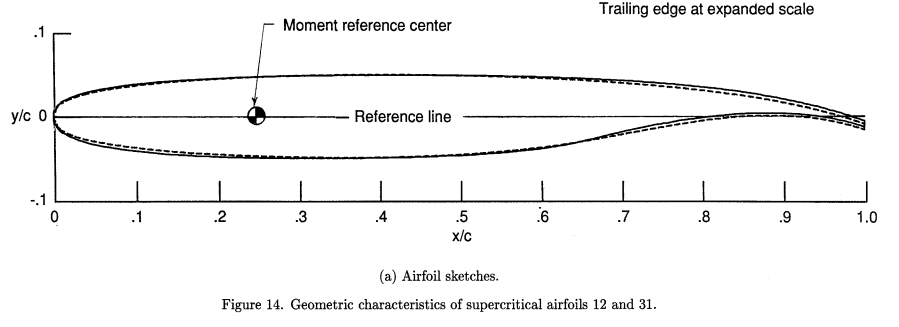
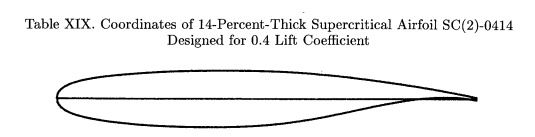
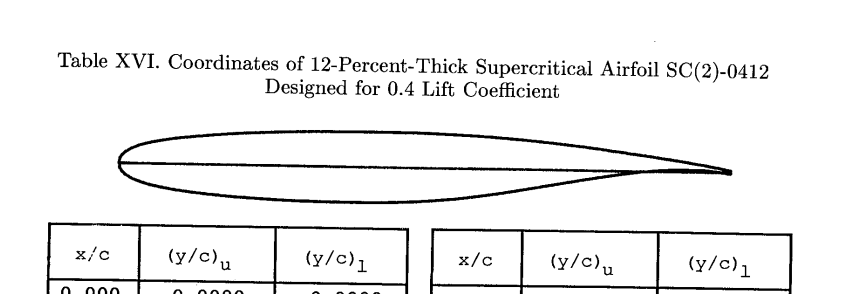
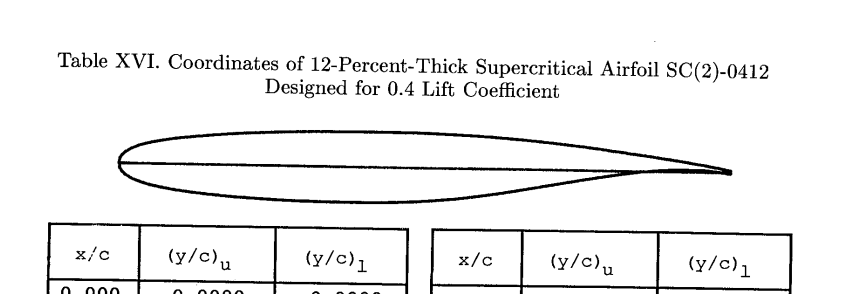

In [ ]:
quarter_chord_sweep = 34.5

In [7]:
math.cos(math.radians(quarter_chord_sweep))

0.8476363543511364

In [9]:
beta = math.sqrt(1-config.cruise_mach**2)
n =  10.81 / (2 * math.pi / beta)
F = 1.07 * (1 + 6.5 / wingspan)**2
h = 2.75 # because reasons
AR_eff = config.aerodynamics.AR * (1 + 1.9 * h / wingspan)
s_exp = 131*2

x = [0.39894459102902374, 0.7641160949868073]
y = [-0.9006342494714588, 1.06553911205074]

y0 = math.radians((x[1] * y[0] - x[0] * y[1]) / (x[1] - x[0]))

sweep_max_t = math.radians(30.5)

CL_a_cruise = 2 * math.pi * AR_eff / (2 + math.sqrt(4 + (AR_eff*beta/n)**2 *(1+ (math.tan(sweep_max_t)/beta)**2))) * (s_exp /  S) * F

beta = math.sqrt(1-(config.stall_speed/c)**2)

CL_a_stall = 2 * math.pi * AR_eff / (2 + math.sqrt(4 + (AR_eff*beta/n)**2 *(1+ (math.tan(sweep_max_t)/beta)**2))) * (s_exp /  S) * F


AoA_cruise = cruise_cl / CL_a_cruise + y0
math.degrees(AoA_cruise)

2.0538872325748567

Taper ratio 0.25 from https://booksite.elsevier.com/9780340741528/appendices/data-a/default.htm

In [10]:
y0

-0.05320898432542515

In [11]:

mac = 6.692
mu = fluids.ATMOSPHERE_1976(config.cruise_altitude).mu
Reynolds = rho_cruise * config.cruise_mach * c / mu

k = 0.634 * 10e-5 # Smooth paint

cutoff_re = 38.21 * (mac / k)**1.053

laminar_cf = 1.328 / math.sqrt(Reynolds)
turbulent_cf = 0.455 / (math.log10(min(Reynolds,cutoff_re))**2.58 * (1 + 0.144 * config.cruise_mach**2)**0.65)


percentage_laminar = 0.15
Cf = laminar_cf * percentage_laminar + turbulent_cf * (1 - percentage_laminar)


In [12]:
max_tc_point = 0.38
thickness_to_chord_mac = 0.088

Ff = (1 + 0.6 / max_tc_point * thickness_to_chord_mac + 100 * thickness_to_chord_mac**4) * (1.34 * config.cruise_mach ** 0.18 * (math.cos(sweep_max_t)) ** 0.28)

In [13]:
Q = 1.01
Cd_increment = 0.015
CD0_cruise = Cf * Ff * Q * s_exp / S + Cd_increment

taper_ratio = 0.25
f_l = 0.005 * (1 + 1.5*(taper_ratio - 0.6)**2)
Ne = 0
thickness_to_chord_mac = 0.088

K = (1 + (0.142 + f_l * config.aerodynamics.AR * (10 * thickness_to_chord_mac) ** 0.33) / (math.cos(math.radians(quarter_chord_sweep)) ** 2) + (0.1 * (3 * Ne + 1)) / (4 + config.aerodynamics.AR) ** 0.8) * (1 + 0.12 * config.cruise_mach ** 6) / (math.pi * config.aerodynamics.AR)


CD_cruise = CD0_cruise + K * cruise_cl**2

ClCd_cruise = cruise_cl / CD_cruise

assert ClCd_cruise > config.aerodynamics.L_D_max, f"Something is wrong, the L/D ratio is lower than assumed: {ClCd_cruise}"

ClCd_cruise

17.144664640589642

In [14]:
s_exp / S

0.778395078201465

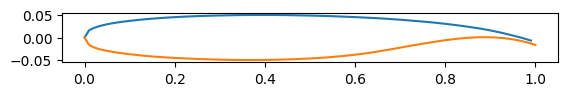

0.9900 -0.0068
0.9800 -0.0037
0.9700 -0.0008
0.9600 0.0019
0.9500 0.0044
0.9400 0.0069
0.9300 0.0093
0.9200 0.0116
0.9100 0.0137
0.9000 0.0157
0.8900 0.0176
0.8800 0.0194
0.8700 0.0210
0.8600 0.0225
0.8500 0.0240
0.8400 0.0254
0.8300 0.0267
0.8200 0.0280
0.8100 0.0292
0.8000 0.0304
0.7900 0.0315
0.7800 0.0326
0.7700 0.0336
0.7600 0.0345
0.7500 0.0354
0.7400 0.0363
0.7300 0.0371
0.7200 0.0379
0.7100 0.0387
0.7000 0.0395
0.6900 0.0402
0.6800 0.0409
0.6700 0.0416
0.6600 0.0422
0.6500 0.0428
0.6400 0.0433
0.6300 0.0438
0.6200 0.0443
0.6100 0.0448
0.6000 0.0453
0.5900 0.0457
0.5800 0.0461
0.5700 0.0465
0.5600 0.0469
0.5500 0.0473
0.5400 0.0476
0.5300 0.0479
0.5200 0.0482
0.5100 0.0485
0.5000 0.0487
0.4900 0.0489
0.4800 0.0491
0.4700 0.0493
0.4600 0.0495
0.4500 0.0497
0.4400 0.0498
0.4300 0.0499
0.4200 0.0500
0.4100 0.0500
0.4000 0.0500
0.3900 0.0500
0.3800 0.0500
0.3700 0.0500
0.3600 0.0499
0.3500 0.0498
0.3400 0.0497
0.3300 0.0495
0.3200 0.0493
0.3100 0.0491
0.3000 0.0489
0.2900 0.0487
0.2

In [7]:
pts = [
[0.0    ,  0.0],
[0.0159 ,  -0.0164],
[0.0209 ,  -0.0215],
[0.0244 ,  -0.0250],
[0.0271 ,  -0.0274],
[0.0294 ,  -0.0295],
[0.0313 ,  -0.0314],
[0.0329 ,  -0.0330],
[0.0344 ,  -0.0344],
[0.0357 ,  -0.0358],
[0.0369 ,  -0.0370],
[0.0380 ,  -0.0381],
[0.0391 ,  -0.0392],
[0.0401 ,  -0.0402],
[0.0410 ,  -0.0411],
[0.0418 ,  -0.0420],
[0.0426 ,  -0.0427],
[0.0433 ,  -0.0434],
[0.0440 ,  -0.0440],
[0.0446 ,  -0.0446],
[0.0452 ,  -0.0452],
[0.0457 ,  -0.0457],
[0.0462 ,  -0.0462],
[0.0467 ,  -0.0467],
[0.0471 ,  -0.0471],
[0.0475 ,  -0.0475],
[0.0478 ,  -0.0479],
[0.0481 ,  -0.0482],
[0.0484 ,  -0.0485],
[0.0487 ,  -0.0488],
[0.0489 ,  -0.0491],
[0.0491 ,  -0.0493],
[0.0493 ,  -0.0495],
[0.0495 ,  -0.0497],
[0.0497 ,  -0.0498],
[0.0498 ,  -0.0499],
[0.0499 ,  -0.0499],
[0.0500 ,  -0.0499],
[0.0500 ,  -0.0499],
[0.0500 ,  -0.0498],
[0.0500 ,  -0.0497],
[0.0500 ,  -0.0495],
[0.0500 ,  -0.0493],
[0.0499 ,  -0.0491],
[0.0498 ,  -0.0488],
[0.0497 ,  -0.0485],
[0.0495 ,  -0.0482],
[0.0493 ,  -0.0478],
[0.0491 ,  -0.0474],
[0.0489 ,  -0.0470],
[0.0487 ,  -0.0465],
[0.0485 ,  -0.0459],
[0.0482 ,  -0.0453],
[0.0479 ,  -0.0446],
[0.0476 ,  -0.0439],
[0.0473 ,  -0.0431],
[0.0469 ,  -0.0422],
[0.0465 ,  -0.0413],
[0.0461 ,  -0.0403],
[0.0457 ,  -0.0392],
[0.0453 ,  -0.0381],
[0.0448 ,  -0.0369],
[0.0443 ,  -0.0356],
[0.0438 ,  -0.0342],
[0.0433 ,  -0.0327],
[0.0428 ,  -0.0311],
[0.0422 ,  -0.0294],
[0.0416 ,   -0.0277],
[0.0409 ,   -0.0260],
[0.0402 ,   -0.0242],
[0.0395 ,   -0.0224],
[0.0387 ,   -0.0206],
[0.0379 ,   -0.0188],
[0.0371 ,   -0.0171],
[0.0363 ,   -0.0154],
[0.0354 ,   -0.0137],
[0.0345 ,   -0.0121],
[0.0336 ,   -0.0105],
[0.0326 ,   -0.0089],
[0.0315 ,   -0.0074],
[0.0304 ,   -0.0060],
[0.0292 ,   -0.0047],
[0.0280 ,   -0.0035],
[0.0267 ,   -0.0024],
[0.0254 ,   -0.0014],
[0.0240 ,   -0.0006],
[0.0225 ,   0.0],
[0.0210 ,   0.0005],
[0.0194 ,   0.0007],
[0.0176 ,   0.0007],
[0.0157 ,   0.0005],
[0.0137 ,   0.0001],
[0.0116 ,   -0.0005],
[0.0093 ,   -0.0014],
[0.0069 ,   -0.0026],
[0.0044 ,   -0.0041],
[0.0019 ,   -0.0059],
[-0.0008,   -0.0080],
[-0.0037,   -0.0105],
[-0.0068,   -0.0133],
[0.0    ,   -0.0164],
]

chords = np.linspace(0, 1, len(pts))

pts = np.array(pts)

x = pts[:, 0] * chords
y = pts[:, 1] * chords

plt.plot(chords[:-1], pts[:, 0][:-1], label="x")
plt.plot(chords, pts[:, 1], label="y")
plt.gca().set_aspect('equal')
plt.show()

print("\n".join([f"{x:.4f} {y:.4f}" for x, y in zip(chords[:-1][::-1], pts[:-1, 0][::-1])]))
print("\n".join([f"{x:.4f} {y:.4f}" for x, y in zip(chords, pts[:, 1])]))

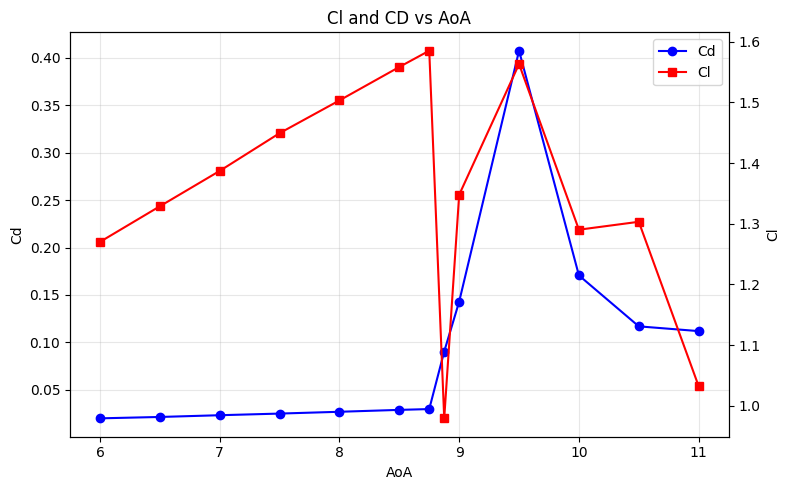

In [18]:
AoAs = np.array([
[6, 0.019972591,	1.270089],
[6.5, 0.021426823,	1.3287697],
[7, 0.023262795,	1.3870493],
[7.5, 0.024991965,	1.4492235],
[8, 0.02689185	,    1.5032299],
[8.5, 0.028891748,	1.5583227],
[8.75, 0.029744394,	1.5851173],
[8.875, 0.090425938,	0.97934884],
[9, 0.14302933	,    1.3477463],
[9.5, 0.40747488	,    1.5631305],
[10, 0.17063549	,    1.2901803],
[10.5, 0.11692991	,    1.3032355],
[11, 0.1119212	,    1.0323422],
])
x = AoAs[:, 0]
y1 = AoAs[:, 1]
y2 = AoAs[:, 2]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis
line1, = ax1.plot(x, y1, 'b-o', label='Cd')
ax1.set_xlabel('AoA')
ax1.set_ylabel('Cd')
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Right y-axis
ax2 = ax1.twinx()
line2, = ax2.plot(x, y2, 'r-s', label='Cl')
ax2.set_ylabel('Cl')
ax2.tick_params(axis='y')

# Combined legend
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best')

plt.title('Cl and CD vs AoA')
plt.tight_layout()
plt.show()


In [19]:
delta_y = 0.02519

le_sweep = 34.6
cL_max_to_cl_max = 0.7368421053

cl_max = max(y2)

a_s_2d = math.radians(max(AoAs, key=lambda x: x[2])[0])

CL_max = cL_max_to_cl_max * cl_max
da_Cl_max = 4.1574

a_s = CL_max / CL_a_stall + y0 + math.radians(da_Cl_max)
math.degrees(a_s)




14.604281880984527

In [25]:
from scipy.interpolate import interp1d
# Trailing edge flap

# Comment out the other value for takeoff. Also fix the assert statement
delta_f = 45
#delta_f = 26

fraction = 0.82

da0l_ddeltaf = np.array([
[-0.045048083408801176, -0.5547726878529168],
[10.079062999865107, -0.551091753550849],
[20.02885968124265, -0.5353446780627881],
[30.206016689471756, -0.500509741949161],
[40.03440035460309, -0.4405374934957315],
[50.02943783846288, -0.3393647979340521],
[55.02702885004529, -0.2892809651371201],
[60.08460367322554, -0.25628456898379304],
[70.09033706565938, -0.22948409104049108],
[79.81132802713485, -0.22277457649983706],
])

dal0 = interp1d(da0l_ddeltaf[:, 0], da0l_ddeltaf[:, 1], kind='cubic')(delta_f).item() * math.radians(delta_f)

print(math.degrees(dal0))

da_s_2d = -4 * 10e-7 * delta_f**4 + 3*10e-5 * delta_f**3 - 0.0019 * delta_f**2 - 0.024 * delta_f
a_s_flapped_2d = a_s_2d + math.radians(da_s_2d)

cl_max_flapped = CL_a_stall * (a_s_flapped_2d - (y0 + dal0))

dclmax = cl_max_flapped - cl_max

K_lambda = (1 - 0.08 * math.cos(math.radians(quarter_chord_sweep))**2) * math.cos(math.radians(quarter_chord_sweep))**0.75


dcLmax = dclmax * fraction * K_lambda

CL_max_flapped = CL_max + dcLmax
a_s_flapped = a_s + math.radians(da_s_2d)

CL_max_flapped

-17.705726118774862


2.1841087761648192

In [26]:
k2_points = np.array([
[-0.154159667112733, -0.00031686116274622106],
[10.126297035985507, 0.0019389950742122325],
[18.553583703818198, 0.006402710606917271],
[25.95031909830831, 0.013077539465281568],
[32.82852482621447, 0.024022469076547016],
[38.36899885702201, 0.03591147411622584],
[43.80729634857168, 0.047167163584151274],
[49.14423080834171, 0.056998401457805443],
[54.89247464907319, 0.06683126634641594],
[61.25686905376875, 0.07745770777997882],
[67.82708085044072, 0.0879267355165163],
[73.6805925588471, 0.09538659909131221],
[76.35117490817532, 0.0982452643695928],
])

k2 = interp1d(k2_points[:, 0], k2_points[:, 1], kind='cubic')(delta_f).item()
k1 = 1.7415730337

dCd0 = k1 * k2 * fraction
dCd0

0.07063035008537932

In [27]:
# Comment out the other value for takeoff. Also fix the assert statement
ext = 1.1
#ext = 1.05

le_fraction = 0.95
dClmax_le = 0.4 * ext

dCLmax_le = dClmax_le * fraction * le_fraction * math.cos(math.radians(le_sweep))

CL_max_flapped_full = CL_max_flapped + dCLmax_le
assert CL_max_flapped_full >= config.aerodynamics.CL_max_l
CL_max_flapped_full

2.4662469978436845

In [28]:
total_drag = CD0_cruise+ dCd0
assert CD0_cruise+ dCd0 < config.aerodynamics.CD0_l
CD0_cruise + dCd0

0.08862576177216791